# Seattle Permit Predictor — Random Forest Model
*5-Fold Cross-Validated Random Forest | Target: `log(1 + totaldaysplanreview)`*

**Goal:** Given an address and project type, predict how long the permit approval process is likely to take.

**Modeling population:** Post-cleaning snapshot from `master_dataset.csv` (14,201 permits). Excludes: null review times, negative/zero review times, review times > 1,095 days, and 2026 permits with incomplete review cycles.

**Features used (all available at submission time):**
- `permittypedesc` — permit type (Addition/Alteration, New, etc.)
- `permitclass` — project class (Single Family/Duplex, Multifamily, Commercial, etc.)
- `zone_family` — zoning prefix reduced to 21 families + Unknown
- `log_estprojectcost` — log-transformed estimated project cost
- `log_housingunitsadded` — log-transformed housing units added
- `latitude`, `longitude` — spatial proxies for neighborhood effects

**Excluded by design:** `dwellingunittype` (inaccurate per liaison), `housingcategory` (assigned post-build, not available at submission), and all post-submission process fields (`daysplanreviewcity`, `numberreviewcycles`, etc.).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
import datetime
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
OUTPUT_DIR = r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output' + '\\'
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [12]:
df = pd.read_csv(f'{OUTPUT_DIR}master_dataset.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df[['totaldaysplanreview', 'log_target']].describe().round(2)

Loaded: 14,201 rows × 45 columns


,totaldaysplanreview,log_target
count,14201.00,14201.00
mean,153.86,4.63
std,155.00,0.94
min,3.00,1.39
25%,52.00,3.97
50%,103.00,4.64
75%,202.00,5.31
max,1094.00,7.00


## 2. Feature Selection & Preprocessing

Categorical features are ordinal-encoded (compatible with tree-based models). Numeric features with nulls are median-imputed. The target is `log_target` = `log(1 + totaldaysplanreview)`, already computed in the dataset.

In [13]:
# --- Feature definitions ---
CAT_FEATURES = ['permittypedesc', 'permitclass', 'zone_family']
NUM_FEATURES = ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = 'log_target'

# Fill categorical nulls with explicit 'Unknown' before encoding
for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown')

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print('Feature set:')
print(f'  Categorical : {CAT_FEATURES}')
print(f'  Numeric     : {NUM_FEATURES}')
print(f'\nX shape: {X.shape} | y shape: {y.shape}')
print(f'\nNull counts per feature:')
print(X.isnull().sum())

Feature set:
  Categorical : ['permittypedesc', 'permitclass', 'zone_family']
  Numeric     : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']

X shape: (14201, 7) | y shape: (14201,)

Null counts per feature:
permittypedesc             0
permitclass                0
zone_family                0
log_estprojectcost        45
log_housingunitsadded    237
latitude                  19
longitude                 19
dtype: int64


In [14]:
# --- Preprocessing pipeline ---
# Categorical: OrdinalEncoder (handles unseen values gracefully for RF)
# Numeric: median imputation for the small null fraction

cat_pipe = Pipeline([
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
], remainder='drop')

print('Preprocessor configured.')

Preprocessor configured.


## 3. Baseline Random Forest — 5-Fold Cross Validation

Initial model uses scikit-learn defaults as a baseline before hyperparameter tuning. Evaluation metrics are computed on log-scale (primary) and back-transformed to days (interpretable).

In [15]:
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', rf_baseline)
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Collect per-fold metrics manually for full transparency
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model_pipeline.fit(X_train, y_train)
    y_pred_log = model_pipeline.predict(X_val)
    
    # Log-scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)
    
    # Back-transform to days: exp(log_pred) - 1  [since target = log(1 + days)]
    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)
    
    fold_results.append({
        'fold': fold,
        'rmse_log': rmse_log,
        'mae_log': mae_log,
        'r2': r2,
        'rmse_days': rmse_days,
        'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

results_df = pd.DataFrame(fold_results)
print('\n--- 5-Fold CV Summary (Baseline RF) ---')
print(results_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4))

Fold 1 | R²=0.3170 | RMSE(log)=0.7649 | MAE(days)=72.0
Fold 2 | R²=0.3325 | RMSE(log)=0.7623 | MAE(days)=75.5
Fold 3 | R²=0.3158 | RMSE(log)=0.7665 | MAE(days)=76.3
Fold 4 | R²=0.3364 | RMSE(log)=0.7593 | MAE(days)=74.2
Fold 5 | R²=0.3475 | RMSE(log)=0.7724 | MAE(days)=72.7

--- 5-Fold CV Summary (Baseline RF) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.7651   0.5790  0.3298   127.2035   74.1430
std     0.0049   0.0028  0.0134     5.0501    1.8217


## 4. Hyperparameter Tuning

Grid search over key Random Forest hyperparameters using 5-fold CV. Scoring on negative RMSE (log-scale).

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'rf__n_estimators': [200, 400],
    'rf__max_depth': [None, 20, 30],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features': ['sqrt', 0.5]
}

grid_search = GridSearchCV(
    estimator=Pipeline([
        ('prep', preprocessor),
        ('rf', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print('\nBest parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV RMSE (log): {-grid_search.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters:
  rf__max_depth: 20
  rf__max_features: sqrt
  rf__min_samples_leaf: 5
  rf__n_estimators: 400

Best CV RMSE (log): 0.7472


## 5. Final Model — Tuned RF with 5-Fold CV

Refit the tuned model and collect full per-fold metrics.

In [17]:
best_params = {k.replace('rf__', ''): v for k, v in grid_search.best_params_.items()}

rf_tuned = RandomForestRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tuned_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', rf_tuned)
])

tuned_results = []
oof_preds = np.zeros(len(y))   # out-of-fold predictions for residual analysis

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    tuned_pipeline.fit(X_train, y_train)
    y_pred_log = tuned_pipeline.predict(X_val)
    oof_preds[val_idx] = y_pred_log
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
    mae_log  = mean_absolute_error(y_val, y_pred_log)
    r2       = r2_score(y_val, y_pred_log)
    
    y_val_days  = np.expm1(y_val)
    y_pred_days = np.expm1(y_pred_log)
    rmse_days   = np.sqrt(mean_squared_error(y_val_days, y_pred_days))
    mae_days    = mean_absolute_error(y_val_days, y_pred_days)
    
    tuned_results.append({
        'fold': fold,
        'rmse_log': rmse_log,
        'mae_log': mae_log,
        'r2': r2,
        'rmse_days': rmse_days,
        'mae_days': mae_days
    })
    print(f'Fold {fold} | R²={r2:.4f} | RMSE(log)={rmse_log:.4f} | MAE(days)={mae_days:.1f}')

tuned_df = pd.DataFrame(tuned_results)
print('\n--- 5-Fold CV Summary (Tuned RF) ---')
summary = tuned_df.drop('fold', axis=1).describe().loc[['mean', 'std']].round(4)
print(summary)

Fold 1 | R²=0.3554 | RMSE(log)=0.7431 | MAE(days)=74.1
Fold 2 | R²=0.3608 | RMSE(log)=0.7459 | MAE(days)=77.3
Fold 3 | R²=0.3447 | RMSE(log)=0.7501 | MAE(days)=77.7
Fold 4 | R²=0.3714 | RMSE(log)=0.7390 | MAE(days)=76.4
Fold 5 | R²=0.3717 | RMSE(log)=0.7579 | MAE(days)=74.3

--- 5-Fold CV Summary (Tuned RF) ---
      rmse_log  mae_log      r2  rmse_days  mae_days
mean    0.7472   0.5730  0.3608   132.1998   75.9771
std     0.0072   0.0046  0.0114     4.4454    1.6739


## 6. Model Evaluation Plots

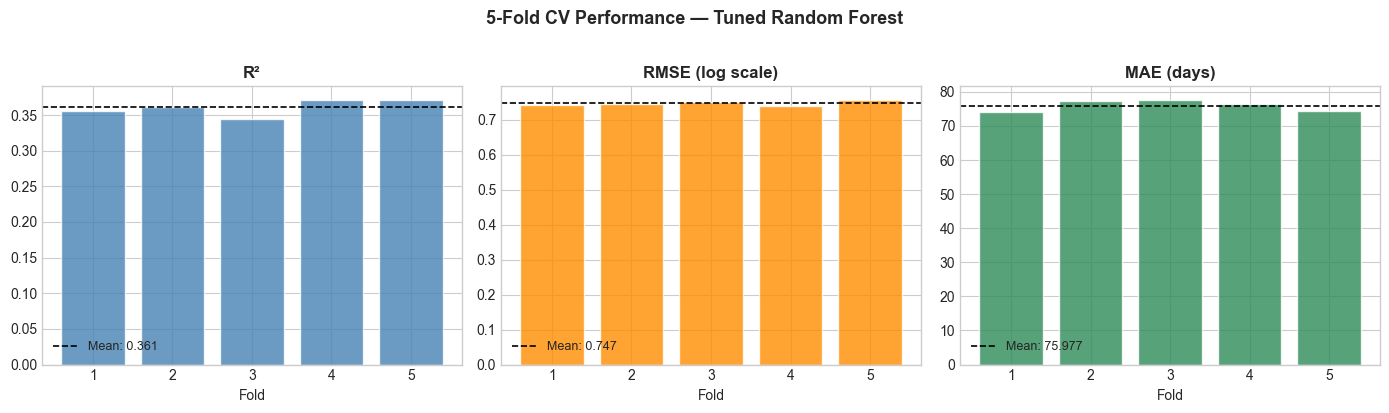

Saved: cv_metrics_per_fold.png


In [18]:
# --- 6a. Per-fold metrics bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [('r2', 'R²', 'steelblue'), ('rmse_log', 'RMSE (log scale)', 'darkorange'), ('mae_days', 'MAE (days)', 'seagreen')]

for ax, (col, label, color) in zip(axes, metrics):
    bars = ax.bar(tuned_df['fold'], tuned_df[col], color=color, alpha=0.8, edgecolor='white')
    mean_val = tuned_df[col].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.3f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(tuned_df['fold'])
    ax.legend(fontsize=9)

plt.suptitle('5-Fold CV Performance — Tuned Random Forest', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}cv_metrics_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_metrics_per_fold.png')

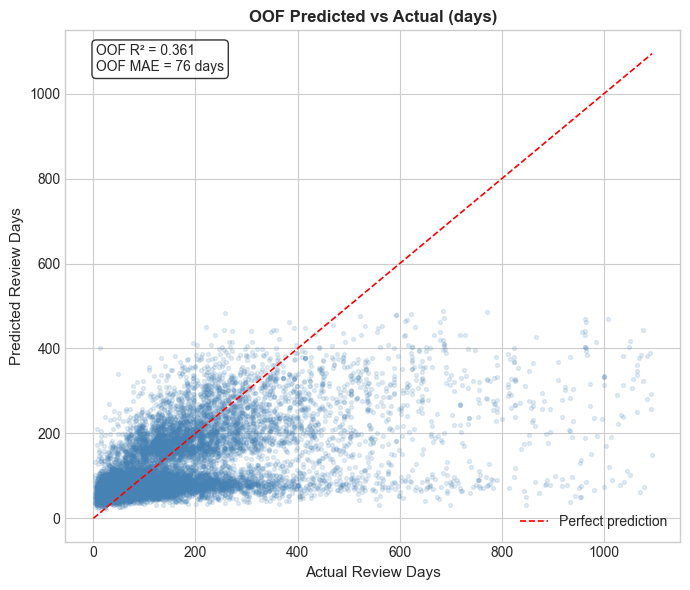

Saved: oof_pred_vs_actual.png


In [19]:
# --- 6b. Predicted vs Actual (OOF, back-transformed to days) ---
actual_days = np.expm1(y.values)
pred_days   = np.expm1(oof_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual_days, pred_days, alpha=0.15, s=8, color='steelblue', rasterized=True)
max_val = max(actual_days.max(), pred_days.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Review Days', fontsize=11)
ax.set_ylabel('Predicted Review Days', fontsize=11)
ax.set_title('OOF Predicted vs Actual (days)', fontsize=12, fontweight='bold')
ax.legend()

overall_r2  = r2_score(y.values, oof_preds)
overall_mae = mean_absolute_error(actual_days, pred_days)
ax.text(0.05, 0.92, f'OOF R² = {overall_r2:.3f}\nOOF MAE = {overall_mae:.0f} days',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}oof_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: oof_pred_vs_actual.png')

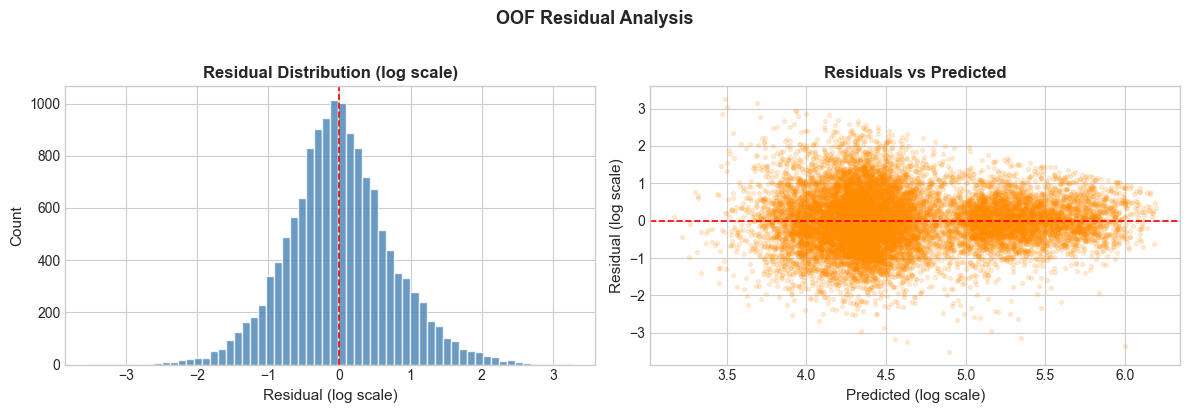

Saved: residual_analysis.png


In [20]:
# --- 6c. Residual distribution ---
residuals_log = y.values - oof_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals_log, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Residual (log scale)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Residual Distribution (log scale)', fontsize=12, fontweight='bold')

axes[1].scatter(oof_preds, residuals_log, alpha=0.15, s=8, color='darkorange', rasterized=True)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Predicted (log scale)', fontsize=11)
axes[1].set_ylabel('Residual (log scale)', fontsize=11)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')

plt.suptitle('OOF Residual Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: residual_analysis.png')

## 7. Feature Importance

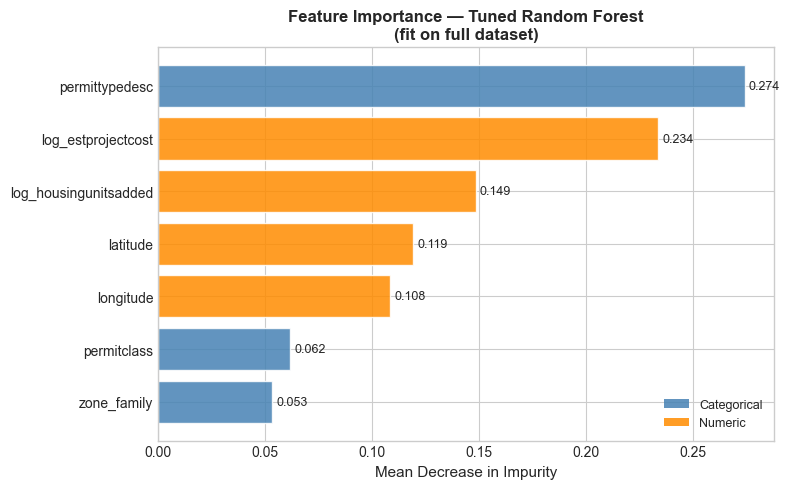

Saved: feature_importance.png

              feature  importance
       permittypedesc    0.274251
   log_estprojectcost    0.234008
log_housingunitsadded    0.148533
             latitude    0.119376
            longitude    0.108470
          permitclass    0.061911
          zone_family    0.053451


In [21]:
# Refit tuned model on full dataset for feature importance
tuned_pipeline.fit(X, y)

feature_names = CAT_FEATURES + NUM_FEATURES
importances = tuned_pipeline.named_steps['rf'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if f in CAT_FEATURES else 'darkorange' for f in imp_df['feature']]
bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.85, label='Categorical'),
                   Patch(facecolor='darkorange', alpha=0.85, label='Numeric')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Feature Importance — Tuned Random Forest\n(fit on full dataset)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')
print()
print(imp_df.sort_values('importance', ascending=False).to_string(index=False))

## 8. Prediction by Permit Type & Zone

Summarize median predicted review time (back-transformed to days) by `permittypedesc` and `permitclass`, to validate that model predictions align with known EDA patterns.

In [22]:
df_pred = df.copy()
for col in CAT_FEATURES:
    df_pred[col] = df_pred[col].fillna('Unknown')

df_pred['predicted_log'] = tuned_pipeline.predict(df_pred[ALL_FEATURES])
df_pred['predicted_days'] = np.expm1(df_pred['predicted_log'])
df_pred['actual_days'] = np.expm1(df_pred['log_target'])

print('=== Median Predicted vs Actual Days by Permit Type ===')
pt = df_pred.groupby('permittypedesc').agg(
    n=('actual_days','count'),
    actual_median=('actual_days','median'),
    predicted_median=('predicted_days','median')
).round(1).sort_values('actual_median', ascending=False)
print(pt.to_string())

print('\n=== Median Predicted vs Actual Days by Permit Class ===')
pc = df_pred.groupby('permitclass').agg(
    n=('actual_days','count'),
    actual_median=('actual_days','median'),
    predicted_median=('predicted_days','median')
).round(1).sort_values('actual_median', ascending=False)
print(pc.to_string())

=== Median Predicted vs Actual Days by Permit Type ===
                                          n  actual_median  predicted_median
permittypedesc                                                              
New                                    4028          216.0             208.6
Change of Use Only - No Construction     27           97.0              80.8
Unknown                                   7           83.0             209.2
Addition/Alteration                   10101           72.0              74.8
Demolition                               37           62.0              85.0
Deconstruction                            1           23.0              78.7

=== Median Predicted vs Actual Days by Permit Class ===
                          n  actual_median  predicted_median
permitclass                                                 
Multifamily             861          295.0             305.6
Institutional             5          259.0             187.5
Vacant Land              19 

## 9. Inference Function

Helper function to generate a prediction for a new permit submission. Accepts the features available at submission time and returns a predicted review time in days with a confidence interval derived from the individual tree predictions.

In [23]:
def predict_permit_review_time(
    permittypedesc: str,
    permitclass: str,
    zone_family: str,
    estprojectcost: float = None,
    housingunitsadded: float = None,
    latitude: float = None,
    longitude: float = None,
    pipeline=tuned_pipeline,
    n_trees_ci: bool = True
) -> dict:
    """
    Predict permit review time for a new submission.

    Parameters
    ----------
    permittypedesc    : e.g. 'New', 'Addition/Alteration'
    permitclass       : e.g. 'Single Family/Duplex', 'Multifamily', 'Commercial'
    zone_family       : e.g. 'SF', 'LR', 'NR', 'NC', 'Unknown'
    estprojectcost    : estimated project cost in dollars (None = median imputed)
    housingunitsadded : number of units added (None = median imputed)
    latitude          : decimal degrees (None = median imputed)
    longitude         : decimal degrees (None = median imputed)
    n_trees_ci        : if True, derive 80% CI from individual tree predictions

    Returns
    -------
    dict with keys: predicted_days, ci_low_days, ci_high_days, predicted_log
    """
    log_cost   = np.log1p(estprojectcost)    if estprojectcost    is not None else np.nan
    log_units  = np.log1p(housingunitsadded) if housingunitsadded is not None else np.nan

    row = pd.DataFrame([{
        'permittypedesc':      permittypedesc,
        'permitclass':         permitclass,
        'zone_family':         zone_family,
        'log_estprojectcost':  log_cost,
        'log_housingunitsadded': log_units,
        'latitude':            latitude  if latitude  is not None else np.nan,
        'longitude':           longitude if longitude is not None else np.nan,
    }])

    pred_log   = pipeline.predict(row)[0]
    pred_days  = np.expm1(pred_log)

    result = {
        'predicted_days': round(pred_days, 1),
        'predicted_log': round(pred_log, 4)
    }

    if n_trees_ci:
        # Get predictions from each tree for a distribution-based interval
        prep  = pipeline.named_steps['prep']
        rf    = pipeline.named_steps['rf']
        X_t   = prep.transform(row)
        tree_preds = np.array([t.predict(X_t)[0] for t in rf.estimators_])
        ci_low  = np.expm1(np.percentile(tree_preds, 10))
        ci_high = np.expm1(np.percentile(tree_preds, 90))
        result['ci_low_days']  = round(ci_low, 1)
        result['ci_high_days'] = round(ci_high, 1)

    return result


# --- Example predictions ---
examples = [
    {'permittypedesc': 'New', 'permitclass': 'Single Family/Duplex',
     'zone_family': 'SF', 'estprojectcost': 500_000, 'housingunitsadded': 1,
     'latitude': 47.65, 'longitude': -122.35},

    {'permittypedesc': 'Addition/Alteration', 'permitclass': 'Single Family/Duplex',
     'zone_family': 'NR', 'estprojectcost': 80_000, 'housingunitsadded': 1,
     'latitude': 47.60, 'longitude': -122.32},

    {'permittypedesc': 'New', 'permitclass': 'Multifamily',
     'zone_family': 'LR', 'estprojectcost': 2_000_000, 'housingunitsadded': 8,
     'latitude': 47.68, 'longitude': -122.34},

    {'permittypedesc': 'New', 'permitclass': 'Commercial',
     'zone_family': 'NC', 'estprojectcost': 1_500_000, 'housingunitsadded': 0,
     'latitude': 47.61, 'longitude': -122.33},
]

print('=== Example Predictions ===')
for ex in examples:
    result = predict_permit_review_time(**ex)
    label = f"{ex['permittypedesc']} | {ex['permitclass']} | zone={ex['zone_family']}"
    print(f"\n{label}")
    print(f"  Predicted : {result['predicted_days']:.0f} days")
    if 'ci_low_days' in result:
        print(f"  80% CI    : {result['ci_low_days']:.0f} – {result['ci_high_days']:.0f} days")

=== Example Predictions ===

New | Single Family/Duplex | zone=SF
  Predicted : 167 days
  80% CI    : 103 – 246 days

Addition/Alteration | Single Family/Duplex | zone=NR
  Predicted : 74 days
  80% CI    : 46 – 114 days

New | Multifamily | zone=LR
  Predicted : 396 days
  80% CI    : 250 – 618 days

New | Commercial | zone=NC
  Predicted : 149 days
  80% CI    : 55 – 372 days


## 10. Save Model Weights

In [24]:
model_save_path = f'{OUTPUT_DIR}ModelWeights_RF.joblib'
joblib.dump(tuned_pipeline, model_save_path)
print(f'Model saved: {model_save_path}')

Model saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\ModelWeights_RF.joblib


## 11. Full Diagnostic Report

All outputs from sections 3–9 consolidated in one place for easy troubleshooting.

In [25]:
sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — RANDOM FOREST DIAGNOSTIC REPORT')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Dataset ────────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] DATASET')
lines.append(sep2)
lines.append(f'  Rows in modeling population : {len(df):,}')
lines.append(f'  Features (categorical)      : {CAT_FEATURES}')
lines.append(f'  Features (numeric)          : {NUM_FEATURES}')
lines.append(f'  Target                      : log(1 + totaldaysplanreview)')
lines.append('')
lines.append('  Null counts per feature:')
for col, n in X.isnull().sum().items():
    pct = n / len(X) * 100
    lines.append(f'    {col:<28} {n:>5}  ({pct:.1f}%)')

# ── 2. Baseline CV ────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 2 ] BASELINE RANDOM FOREST — 5-FOLD CV')
lines.append(sep2)
lines.append(f'  n_estimators=200, all other params=default')
lines.append('')
header = f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}"
lines.append(header)
lines.append('  ' + '-' * 60)
for _, row in results_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = results_df.drop('fold', axis=1).mean()
s = results_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 3. Grid Search ────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 3 ] HYPERPARAMETER TUNING — GRID SEARCH RESULTS')
lines.append(sep2)
lines.append(f'  Best CV RMSE (log): {-grid_search.best_score_:.4f}')
lines.append('  Best parameters:')
for k, v in grid_search.best_params_.items():
    lines.append(f'    {k:<30} {v}')
lines.append('')
lines.append('  Full grid results (mean_test_score = neg RMSE):')
cv_res = pd.DataFrame(grid_search.cv_results_)
cols_show = ['param_rf__n_estimators','param_rf__max_depth','param_rf__min_samples_leaf',
             'param_rf__max_features','mean_test_score','std_test_score','rank_test_score']
cv_res_show = cv_res[cols_show].sort_values('rank_test_score')
cv_res_show.columns = ['n_est','max_depth','min_leaf','max_feat','mean_neg_rmse','std','rank']
lines.append(f'  {cv_res_show.to_string(index=False)}')

# ── 4. Tuned CV ───────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 4 ] TUNED RANDOM FOREST — 5-FOLD CV')
lines.append(sep2)
lines.append(f"  {'Fold':>4}  {'R²':>7}  {'RMSE(log)':>10}  {'MAE(log)':>9}  {'RMSE(days)':>11}  {'MAE(days)':>10}")
lines.append('  ' + '-' * 60)
for _, row in tuned_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.r2:>7.4f}  {row.rmse_log:>10.4f}  {row.mae_log:>9.4f}  {row.rmse_days:>11.1f}  {row.mae_days:>10.1f}")
lines.append('  ' + '-' * 60)
m = tuned_df.drop('fold', axis=1).mean()
s = tuned_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.r2:>7.4f}  {m.rmse_log:>10.4f}  {m.mae_log:>9.4f}  {m.rmse_days:>11.1f}  {m.mae_days:>10.1f}")
lines.append(f"  {'STD':>4}  {s.r2:>7.4f}  {s.rmse_log:>10.4f}  {s.mae_log:>9.4f}  {s.rmse_days:>11.1f}  {s.mae_days:>10.1f}")

# ── 5. OOF Summary ────────────────────────────────────────────────────────
lines.append('')
lines.append('[ 5 ] OUT-OF-FOLD (OOF) AGGREGATE METRICS')
lines.append(sep2)
oof_r2   = r2_score(y.values, oof_preds)
oof_rmse = np.sqrt(mean_squared_error(y.values, oof_preds))
oof_mae  = mean_absolute_error(y.values, oof_preds)
oof_mae_days = mean_absolute_error(np.expm1(y.values), np.expm1(oof_preds))
residuals = y.values - oof_preds
lines.append(f'  OOF R²              : {oof_r2:.4f}')
lines.append(f'  OOF RMSE (log)      : {oof_rmse:.4f}')
lines.append(f'  OOF MAE  (log)      : {oof_mae:.4f}')
lines.append(f'  OOF MAE  (days)     : {oof_mae_days:.1f}')
lines.append(f'  Residual mean       : {residuals.mean():.4f}  (bias check; ideal = 0)')
lines.append(f'  Residual std        : {residuals.std():.4f}')
lines.append(f'  Residual skewness   : {pd.Series(residuals).skew():.4f}')
lines.append(f'  Residual kurtosis   : {pd.Series(residuals).kurt():.4f}')

# ── 6. Feature Importance ─────────────────────────────────────────────────
lines.append('')
lines.append('[ 6 ] FEATURE IMPORTANCE (full-dataset fit, MDI)')
lines.append(sep2)
imp_sorted = imp_df.sort_values('importance', ascending=False)
for _, row in imp_sorted.iterrows():
    bar = '█' * int(row['importance'] * 100)
    lines.append(f'  {row["feature"]:<28}  {row["importance"]:.4f}  {bar}')

# ── 7. Sanity Check Tables ────────────────────────────────────────────────
lines.append('')
lines.append('[ 7 ] SANITY CHECK — MEDIAN PREDICTED vs ACTUAL DAYS')
lines.append(sep2)
lines.append('  By Permit Type (permittypedesc):')
lines.append(f'  {pt.to_string()}')
lines.append('')
lines.append('  By Permit Class (permitclass):')
lines.append(f'  {pc.to_string()}')

# ── 8. Example Predictions ────────────────────────────────────────────────
lines.append('')
lines.append('[ 8 ] EXAMPLE INFERENCE PREDICTIONS')
lines.append(sep2)
for ex in examples:
    result = predict_permit_review_time(**ex)
    label = f"{ex['permittypedesc']} | {ex['permitclass']} | zone={ex['zone_family']} | cost=${ex.get('estprojectcost',0):,}"
    lines.append(f'  {label}')
    lines.append(f'    Predicted : {result["predicted_days"]:.0f} days')
    if 'ci_low_days' in result:
        lines.append(f'    80% CI    : {result["ci_low_days"]:.0f} – {result["ci_high_days"]:.0f} days')
    lines.append('')

# ── 9. Saved Artifacts ────────────────────────────────────────────────────
lines.append('[ 9 ] SAVED ARTIFACTS')
lines.append(sep2)
artifacts = [
    'ModelWeights_RF.joblib      — fitted pipeline (preprocessor + tuned RF)',
    'cv_metrics_per_fold.png     — per-fold R², RMSE, MAE bar charts',
    'oof_pred_vs_actual.png      — OOF predicted vs actual scatter',
    'residual_analysis.png       — residual histogram and residuals vs predicted',
    'feature_importance.png      — MDI feature importance bar chart',
]
for a in artifacts:
    lines.append(f'  {a}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

# Also save as a text file for archiving alongside the model weights
report_path = f'{OUTPUT_DIR}DiagnosticReport_RF.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')

  SEATTLE PERMIT PREDICTOR — RANDOM FOREST DIAGNOSTIC REPORT
  Generated: 2026-05-12 18:09:44

[ 1 ] DATASET
----------------------------------------------------------------------
  Rows in modeling population : 14,201
  Features (categorical)      : ['permittypedesc', 'permitclass', 'zone_family']
  Features (numeric)          : ['log_estprojectcost', 'log_housingunitsadded', 'latitude', 'longitude']
  Target                      : log(1 + totaldaysplanreview)

  Null counts per feature:
    permittypedesc                   0  (0.0%)
    permitclass                      0  (0.0%)
    zone_family                      0  (0.0%)
    log_estprojectcost              45  (0.3%)
    log_housingunitsadded          237  (1.7%)
    latitude                        19  (0.1%)
    longitude                       19  (0.1%)

[ 2 ] BASELINE RANDOM FOREST — 5-FOLD CV
----------------------------------------------------------------------
  n_estimators=200, all other params=default

  Fold       R²   

UnicodeEncodeError: 'charmap' codec can't encode characters in position 5985-6011: character maps to <undefined>